In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [8]:
df = pd.read_csv("train.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [38]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
df["month"] = df["Order Date"].dt.month
print(df.head())

   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Category 

In [15]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
month             0
dtype: int64

In [19]:
total_sales = float(df["Sales"].sum())
print("Total sale : ",total_sales)

Total sale :  2261536.7827


In [24]:
grouped_category = df.groupby("Category")["Sales"].sum()
print(grouped_category)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [31]:
float(df["Sales"].mean())

230.76905945918367

In [40]:
product_sales = df.groupby("Product Name")["Sales"].sum()
best_product = product_sales.idxmax()
print("Best seller : ",best_product)
print(df.columns)

Best seller :  Canon imageCLASS 2200 Advanced Copier
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'month'],
      dtype='str')


In [42]:
monthly_sales = df.groupby("month")["Sales"].sum()
best_sale_month = monthly_sales.idxmax()
worst_sale_month = monthly_sales.idxmin()
print("Best month : ",best_sale_month)
print("Bad month : ",worst_sale_month)


Best month :  11
Bad month :  2


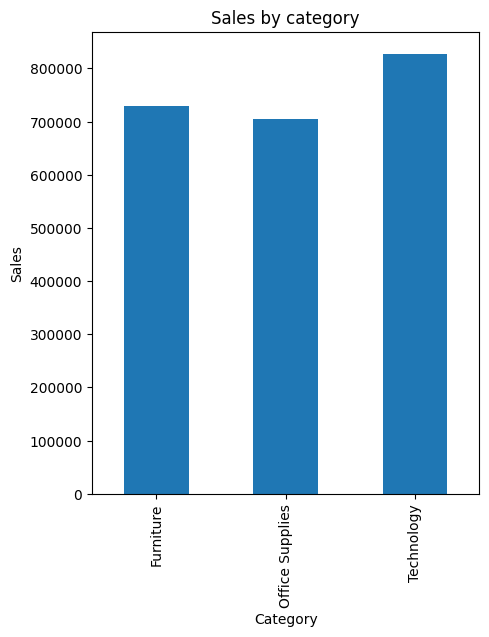

In [50]:
category_sales = df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(5,6))
category_sales.plot(kind="bar")
plt.title("Sales by category")
plt.xlabel("Category")
plt.ylabel("Sales")
# plt.xticks(rotation=45)
plt.show()

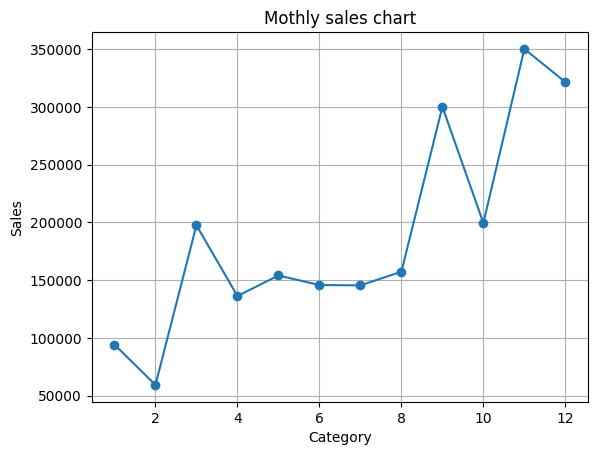

In [51]:
monthly_sales = df.groupby("month")["Sales"].sum()
monthly_sales.plot(kind="line",marker = "o")
plt.title("Mothly sales chart")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.grid(True)
plt.show()